# 基于稀疏自编码器的指数择时模型

1. 研究背景
关于股票指数的量价择时策略，各种研究报告中对其已经有过一定程度的探讨，这些策略总体可分为以下几类:

各种均线及其衍生策略，这种策略主要是根据指数本身价格的不同周期均线进行组合形成相应的买卖点, 该种策略存在以下问题:
被动地应对行情，并未对市场进行预测和验证，因此胜率较低；

本质上是趋势跟踪, 在拐点来到时反应较为迟钝;

如果是日频级别的技术分析，则过度依赖于市场状态，尤其在震荡市信号变换频率较大，会出现来回亏损的情况；

参数方面，容易出现过拟合，比如往往出现选择训练集最优参数，而在样本外失灵的情况。

技术分析择时策略，该策略本质上是构建一些复杂的技术指标并进行线性融合从而对未来指数的涨跌情况进行预判，但该方法依然存在一些问题:
择时特征并不能像股票领域的截面 alpha 因子一样，贡献较为稳健的超额收益，在不同市场风格下，大多数择时特征的绩效表现会出现不同程度的波动，甚至出现失效的风险；

指数价格走势影响因素众多，各种因素之间的作用关系较为复杂，线性方法虽然简单，但是拟合程度也相应较低，无法刻画真实世界中的深度非线性关系，导致策略样本外预测的时候可能存在较大的欠拟合风险;

通过人工筛选指标的方式，最终使用的信息较少，在几百个指标中最后筛选出几个较好的指标，最后合成信号只利用到了这几个指标的信息，而剩下的指标仍有很多的信息尚未被利用。

基于机器学习的择时策略，该策略主要是将指数的一些量价指标通过各类机器学习模型(如决策树、MLP 等)进行非线性拟合从而形成指数的涨跌信号，该方法虽然能捕捉一些人工方法难以捕捉的非线性关系, 但该方法也存在较多不足:
机器学习模型通常参数量较大，但择时任务通常数据量较小，因而模型可能产生较大的过拟合风险。

金融数据噪声含量较高，而一般的机器学习模型往往鲁棒性不足，因此模型很可能学习到一些噪声规律导致模型出现失效风险。

本质上, 我们面临的择时问题是特征压缩、信息筛选和时序预测相结合的问题, 这类问题是统计学中非常重要的领域, 近些年来, 以自编码模型(Auto Encoder, AE)和循环神经网络(Recurrent Neural Networks, RNN)为代表的深度学习(Deep Learning)模型发展迅速，由于其复杂的网络结构设计，拟合能力和特征提取能力远超传统机器学习模型，被大量运用在时间序列预测问题上。并且这些神经网络模型灵活度相对较高, 我们可以通过对其的损失函数和网络结构进行调整使得其能够更好的适应不同任务从而有更出色的表现。

基于上述情况，我们希望对 AE 和 RNN 模型进行一定的精细化设计，使得该模型能够对一些常见的宽基指数未来涨跌进行预测，并且希望新模型能够克服传统择时策略的不足。

2. 择时模型简介
由于指数择时任务数据量相对较少，而神经网络模型的参数量相对较高，因此对于使用的神经网络模型, 我们希望其能满足以下三条性质:

模型能够自助进行特征筛选和信息提纯，择时特征通常在样本外绩效表现波动较大，人工方法很难界定各个特征的有效性，模型代替人工进行特征筛选可以有效的提升策略的泛化能力。

模型自身鲁棒性强, 这样可以避免因数据量不足导致模型的过拟合风险。

满足上述性质的同时，能够较好的学习到指数涨跌的 “真实” 规律。

2.1. 稀疏自编码 (SAE) 模型简介
一方面，由于涉及特征压缩任务，各类神经网络模型中自编码在这个任务中表现最为出色，另外一方面, 我们希望模型能够满足前文提到的三条性质, 因此我们对自编码模型进行改进提出了稀疏自编码模型 ( Sparse Auto Encoder, SAE)[1]。

SAE 模型主要分为两部分，稀疏自编码器与预测器，其中稀疏自编码器主要是对原始的高维特征进行压缩形成低维编码特征, 然后通过低维编码特征将原始特征进行还原, 一方面我们希望编码特征较为稀疏(稀疏化有助于过滤噪声和无效特征的影响)，另外一方面我们希望还原得到的特征与原始特征相似度高从而保证编码向量能够继承原始特征的大部分有效信息, 因此构建相应的损失函数的时候我们会设置自回归损失和稀疏惩罚两项。对于预测器，我们会将自编码层输出的隐藏层特征通过一个 Predictor 结构得到最终指数未来收益率的预测结果，因此该部分结构对应的损失函数我们设计为度量预测结果与真实标签之差。该模型具体形式如下图所示:

图表1:稀疏自编码模型结构
![4_479_1232_1002_475_0.jpg](../docs/20260202-华源证券-量化择时系列研究之一：基于稀疏自编码器的指数择时/images/4_479_1232_1002_475_0.jpg)

整个 SAE 模型的结构可表示为如下数学公式所示:

$$
{\operatorname{code}}_{i} = \operatorname{Encoder}\left( {x}_{i}\right) \text{ (编码层) }
$$

$$
{\widehat{x}}_{i} = \operatorname{Decoder}\left( {\operatorname{code}}_{i}\right) \text{ ( 解码层 ) }
$$

$$
{\widehat{y}}_{i} = \operatorname{Predictor}\left( {{re}{s}_{i}}\right) \text{ ( 预测器 ) }
$$

其中 ${x}_{i}$ 表示输入特征(Input data), ${\operatorname{code}}_{i}$ 表示 ${x}_{i}$ 的压缩编码, ${\widehat{x}}_{i}$ 表示重构特征 (Reconstruction data)，其维度与输入特征维度一致， ${re}{s}_{i}$ 表示隐藏层特征。该模型损失函数设计为:

$$
\operatorname{Loss} = \frac{1}{N}\mathop{\sum }\limits_{{i = 1}}^{N}\left( {\mathcal{J}\left( {{y}_{i},{\widehat{y}}_{i}}\right)  + {\lambda }_{1}\mathcal{L}\left( {{x}_{i},{\widehat{x}}_{i}}\right)  + {\lambda }_{2}\operatorname{SparseLoss}\left( {\operatorname{code}}_{i}\right) }\right)
$$

上述公式中 ${\lambda }_{1}$ 和 ${\lambda }_{2}$ 表示人为调节的权重系数为超参数，函数 $\mathcal{J}$ 和 $\mathcal{L}$ 分别表示向量和矩阵的距离度量函数 ( 如 MSE 损失、KL 散度等 ) , SparseLoss 表示稀疏化惩罚项, 我们通常使用向量范数或 KL 散度来做稀疏化惩罚项 [2], KL 散度的稀疏化损失公式如下:

$$
\mathop{\sum }\limits_{i}\left\lbrack  {\rho \log \frac{\rho }{{\rho }_{i}} + \left( {1 - \rho }\right) \log \left( \frac{1 - \rho }{1 - {\rho }_{i}}\right) }\right\rbrack
$$

其中 ${\rho }_{i}$ 表示整个 batch 样本中第 $i$ 个神经元的平均值, $\rho$ 表示稀疏化参数,该损失相当于把每一个神经元在不同样本上的取值视作为一个分布的随机数,通过让这个随机变量接近于取值为 1 的概率为 $\rho$ , 取值为 0 的概率为 $1 - \rho$ 的伯努利分布随机变量来保证编码向量的稀疏性。

整个模型每年滚动训练，每次训练取五组不同 seed 结果进行平均操作，根据平均信号放到样本外进行预测。训练采用增量训练方式如下图所示:

图表 2: 增量训练过程示意图

![5_655_781_632_339_0.jpg](../docs/20260202-华源证券-量化择时系列研究之一：基于稀疏自编码器的指数择时/images/5_655_781_632_339_0.jpg)

In [1]:
import sys
from pathlib import Path

# 请从本项目目录或 notebook 目录启动内核。
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import seaborn as sns
import torch


# 单线程保证同一 seed 逐位可复现，CLI 也这样做
torch.set_num_threads(1)

# 存储层：模块 DuckDB 的读写入口
# 数据层：TuShare 取数落库，再从库里读成模型输入
from src.data_provider import get_index_dataset # 取数入口：确保覆盖 + 只读校验，一步得到 quotes（2.2）
# 编排层：实验配置与把第 5 章各步串起来的 run（0.8.0 起年度切分在 src.splitter.AnnualExpandingSplit，
# 折内预处理直接用 sklearn 的 SimpleImputer+StandardScaler，原 annual_folds/fit_preprocessor 已删除
from src.generator import ResearchConfig  # 一次实验的全部参数（2.3）
from src.generator import SAETimingGenerator  # run(quotes) 一次跑完所有测试年（2.3）
from src.generator import build_features # 手动获取特征
# 算法层：纯函数，不读写库和文件
from src.factor_algo import \
    threshold_signal  # score → -1/0/1 信号，死区保持前值（2.4）
    
# 画图层
from src.plotting import (
    plot_losses, 
    plot_seed_correlation, 
    plot_signals,
    plot_folds,
    plot_nav_drawdown,
)
%matplotlib inline 

### 2.2. 输入特征说明

模型的输入端我们通常使用一些基于指数日 K 线字段 ( 高开低收、成交额、成交量 ) 构建的常见特征作为模型的输入，特征数量共计 92 个(包含时序滚动平均和特征之间的加减乘除操作得到的一些衍生指标)，这些特征总体可分为四个大类，具体如下:

- 基础 K 线量价字段:当日高开低收除以前收盘价，当日开盘价除以当日收盘价、换手率、 振幅以及它们的滚动 $\mathrm{N}$ 日平均值以及分位数等；

- 均线及均线相对位置指标:滚动 N 日均线、滚动 N 日均线相对滚动 M 日均线位置等；

- 波动率类指标:滚动 N 日收益率及换手率波动率等；

- 基础技术类指标:不同参数下的 RSI、OBV、MACD 等，其中

RSI 指标=(N 日内收盘涨幅绝对值之和)/(N 日内收盘跌幅绝对值之和)

OBV 指标=N 日内收盘涨跌的符号乘以换手率之和

MACD 指标计算方式如下:

DIF=12 日 EMA-26 日 EMA

DEA=DIF 的 9 日 EMA

MACD 指标=DIF-DEA

为了避免过拟合问题, 在构建数据集的时候我们对指标并没有做额外的筛选, 因此上述特征集可能并非最优。并且对于参数 $\mathrm{N}$ 我们通常取不同数值,从而使得截面特征能够尽可能多的包含长短时序信息。

In [2]:
# 取数：缺则联网补拉（缓存命中零网络）；load_index_dataset 纯本地只读（离线/复现，缺数据即报错）
# 换手率口径默认 "require"（真实换手率）；对照量比代理时两个分支都加 turnover_policy="volume_proxy"
FETCH = True
CODE = "000905.SH"
START, END = "2005-01-01", "2025-12-31"   # start_date=训练起点, end_date=样本外终点

index_df: pd.DataFrame = get_index_dataset(START, END, code=CODE)

index_df.tail()


2026-09-22 14:50:37.477 | INFO     | src.data_provider:_datafeed_client:261 - TuShare客户端：DataFeed封装（网关代理）
2026-09-22 14:50:38.367 | INFO     | src.data_provider:get_quotes:452 - TuShare指数000905.SH请求20050101至20251231补1段落库，库内2007-01-15至2025-12-31共4611行
2026-09-22 14:50:38.377 | INFO     | src.data_provider:load_index_dataset:165 - 从DuckDB读取指数000905.SH：2007-01-15至2025-12-31，4611行


,open,high,low,close,preclose,volume,amount,turn
datetime,,,,,,,,
2025-12-25,7341.9223,7426.1367,7334.3404,7410.7119,7352.0396,168414201.0,3.363670e+08,1.51
2025-12-26,7422.6014,7484.9158,7397.4255,7458.8386,7410.7119,199276884.0,3.869143e+08,1.78
2025-12-29,7467.5042,7491.6926,7411.4472,7430.6147,7458.8386,198844338.0,3.904461e+08,1.78
2025-12-30,7390.1398,7495.0606,7389.8691,7458.9360,7430.6147,196203615.0,4.076235e+08,1.76
2025-12-31,7473.7519,7488.0663,7435.0664,7465.5742,7458.9360,194427743.0,3.803696e+08,1.74


In [3]:
# 设置参数
# seeds 取 10：研报 seed 数量是歧义（§2.1 称「取五组不同 seed 结果进行平均」，
# §3.2 称「平行训练十个 seed」并给 10×10 相关矩阵，§4 只说「各个 seed 平均」未给数），
# 本 notebook 统一按 10 个 seed 训练并平均；模块默认 ResearchConfig.seeds=(0,1,2,3,4)。
config = ResearchConfig(
    train_start=START,
    test_start="2020-01-01",
    test_end=END,
    horizon=5,
    seeds=np.arange(10).tolist(),
)  # 2020–2025 逐年扩展训练，10 个 seed，其余默认（字段表见 6.1）

In [4]:
# 构建特征
features_df:pd.DataFrame = build_features(index_df,config.feature_windows, config.ma_pairs, config.rsi_form)

features_df.tail()

,open_prev,high_prev,low_prev,close_prev,open_close,turn,amplitude,macd,close_ma_5,return_5,...,high_prev_mean_250,low_prev_mean_250,rsi_250,obv_250,ma_5_10,ma_5_20,ma_10_20,ma_20_60,ma_60_120,ma_120_250
datetime,,,,,,,,,,,,,,,,,,,,,
2025-12-25,0.998624,1.010078,0.997593,1.007980,0.990718,1.51,0.012486,37.704976,1.016705,0.043639,...,1.007705,0.992663,0.554291,54.15,1.012797,1.020992,1.008091,0.991688,1.045690,1.091958
2025-12-26,1.001604,1.010013,0.998207,1.006494,0.995142,1.78,0.011806,42.801458,1.015249,0.040349,...,1.007737,0.992706,0.558235,57.66,1.016753,1.026026,1.009120,0.994385,1.044033,1.092872
2025-12-29,1.001162,1.004405,0.993646,0.996216,1.004965,1.78,0.010758,41.756204,1.006613,0.024113,...,1.007704,0.992678,0.555950,54.19,1.017138,1.028551,1.011220,0.996230,1.042578,1.093809
2025-12-30,0.994553,1.008673,0.994517,1.003811,0.990777,1.76,0.014157,40.429635,1.004946,0.027857,...,1.007719,0.992705,0.556255,54.18,1.016301,1.031177,1.014637,0.998886,1.040883,1.094785
2025-12-31,1.001986,1.003905,0.996800,1.000890,1.001095,1.74,0.007106,37.520372,1.002772,0.015443,...,1.007693,0.992700,0.555922,54.32,1.014856,1.030971,1.015880,1.002018,1.039150,1.095673


### 2.3. 小波变换去噪

通常金融量价数据噪声含量较高，而神经网络模型通常参数量较大，当模型输入数据量不足的情况下, 容易引发较大的过拟合风险。因此, 我们借助小波变换的方法对时序数据进行分解重构, 进而达到数据去噪的目标。小波变换的主要目标是将原始时间序列内耦合在一起的多尺度特征进行识别分解, 得到时间序列中的长期趋势、中期波动和短期震荡以及噪声成分, 最后保留前三部分使得过滤后的时序数据有效信息成分更高。

小波变换的算法原理主要是选取被称之为父小波 $\varphi$ 和母小波 $\psi$ 的两种小波函数 (它们积分分别为 1 和 0 ，并且各个小波函数彼此正交，即不同的小波函数内积均为 0 )对原始时间序列做卷积，其中，母小波描述时间序列的高频部分，而父小波描述时间序列的低频部分。 进一步地, j 阶的父小波和母小波的形式如下:

$$
{\varphi }_{j, k} = {2}^{-j/2}\varphi \left( {{2}^{-j} - k}\right)
$$

$$
{\psi }_{j, k} = {2}^{-j/2}\psi \left( {{2}^{-j} - k}\right)
$$

而金融时间序列则可以通过对父小波和母小波的一系列投影进行多级分析来重建。级数越多, 模型复杂度越高, 可能导致来自于同一频率成分的信息被强行拆解, 而级数过少可能导致来自于不同频率成分的信息仍然混杂在一起导致各个成分无法被清晰识别, 本算法级别选取为 4 ，即 J 取值为 4 。最后算法通过一组正交波的求和形式来近似一个时间序列，该过程可以表示为:

$$
x\left( t\right)  = \mathop{\sum }\limits_{k}{s}_{J, k}{\varphi }_{J, k} + \mathop{\sum }\limits_{k}{d}_{J, k}{\psi }_{J, k} + \ldots  + \mathop{\sum }\limits_{k}{d}_{1, k}{\psi }_{1, k}
$$

其中小波变换函数前的系数分别可通过如下公式计算:

$$
{s}_{J, k} = \int {\varphi }_{J, k}x\left( s\right) {ds}
$$

$$
{d}_{j, k} = \int {\psi }_{J, k}x\left( s\right) {ds}
$$

通过上述过程对原始标准化后的时间序列进行去噪以后, 我们再将预处理之后的数据放入稀疏自编码模型进行训练和样本外的预测。


In [5]:
# 根据设置的参数进行训练+预测
## 效果分析等过程在SAETimingGenerator进行编排
result = SAETimingGenerator(config).run(index_df)

2026-09-22 14:50:39.377 | INFO     | src.generator:run:251 - 训练2020：2645个训练日，243个预测日，10 seeds
2026-09-22 14:50:45.787 | INFO     | src.generator:run:251 - 训练2021：2888个训练日，243个预测日，10 seeds
2026-09-22 14:50:53.212 | INFO     | src.generator:run:251 - 训练2022：3131个训练日，242个预测日，10 seeds
2026-09-22 14:51:01.035 | INFO     | src.generator:run:251 - 训练2023：3373个训练日，242个预测日，10 seeds
2026-09-22 14:51:09.461 | INFO     | src.generator:run:251 - 训练2024：3615个训练日，242个预测日，10 seeds
2026-09-22 14:51:17.108 | INFO     | src.generator:run:251 - 训练2025：3857个训练日，243个预测日，10 seeds


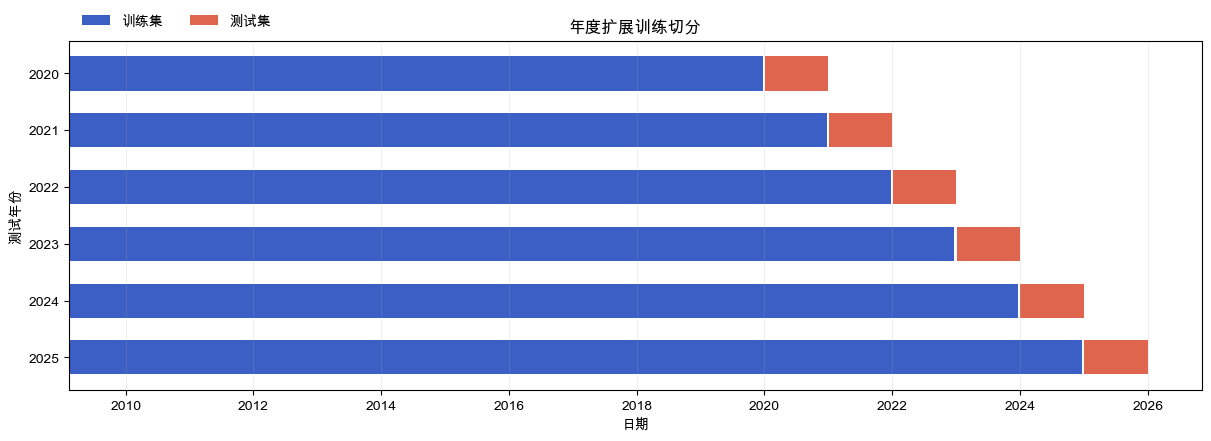

In [6]:
# 展示增量计算过程
plot_folds(result.folds);

### 3.1. 模型训练稳定性分析

由于损失函数含有稀疏化惩罚，两种稀疏化惩罚本质上分别是对数函数和绝对值函数， 这两个函数在原点均不可导, 而由于稀疏化作用编码向量将会有一定比例神经元取值在 0 附近，因此理论上模型训练可能存在不稳定的因素。

为了讨论模型训练是否稳定, 我们绘制了最近一个训练年（2025 年）训练集上分项损失随迭代轮次 epoch 的变化曲线（总损失 / 预测损失 / 重构损失 / 稀疏惩罚四个面板，每个面板 10 条曲线对应 10 个 seed）。可以看到：稀疏惩罚在前 10 轮内由 7 附近迅速降至 0 附近并此后保持平稳，重构损失在第 15–25 轮完成主要下降，预测损失在第 20–60 轮稳步下降，100 轮时各分项均已趋平且 10 个 seed 曲线形态一致、未见发散或持续震荡，说明不可导点并未在实际训练中引发不稳定。其他年份的曲线形态类似, 因此我们文中不再一一展开:

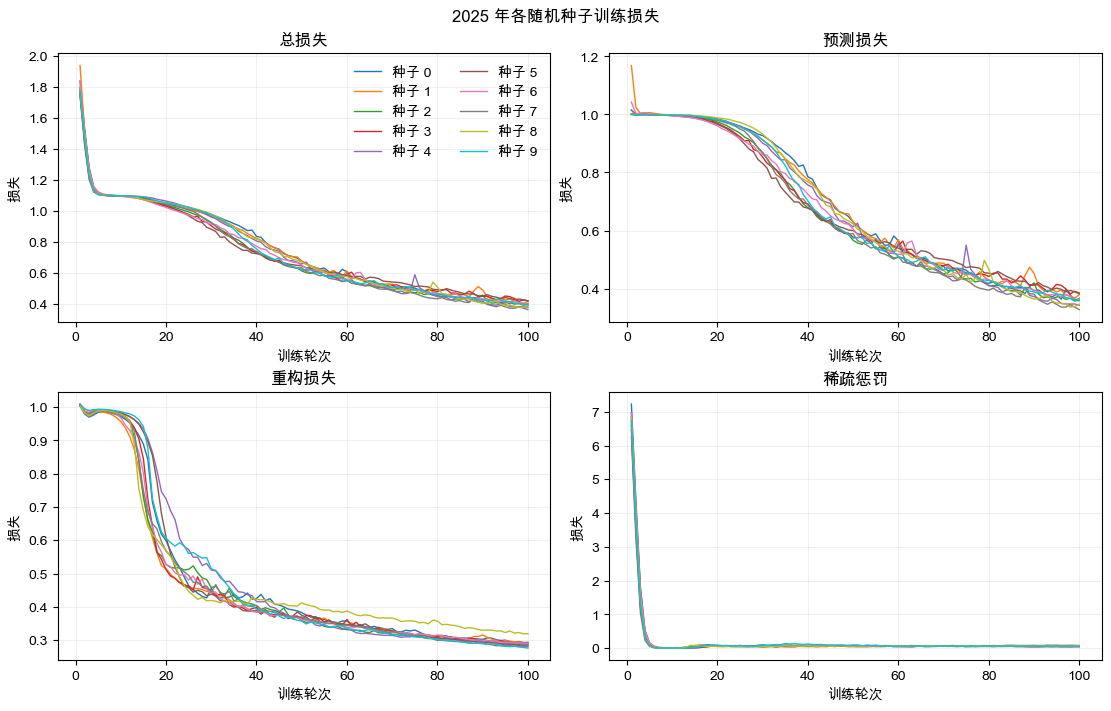

In [7]:
plot_losses(result.losses);

### 3.2. 模型随机性影响

神经网络训练具有一定的随机性, 不同随机种子由于参数初始化、随机梯度下降的路径不同可能导致最终生成不同的信号和样本外策略不同的绩效表现。

为了探究随机性对最终结果造成的影响, 我们每个训练年平行训练 10 个 seed（研报此处口径为歧义：§2.1 写「取五组不同 seed 结果进行平均」，§3.2 写「平行训练十个 seed」，§4 未说几个；本 notebook 统一取 10，模块默认为 5）, 并计算不同 seed 样本外预测值两两之间的相关性，结果见下图：45 对非对角相关系数大多在 0.70 以上，最高 0.84（seed_8–seed_9），最低 0.65（seed_4–seed_5、seed_5–seed_6）。研报图表 4 的对应区间为最低 59.48%（seed6–seed7）、大部分在 70% 以上，形态一致但不逐值可比（模型设定与样本区间均不同）。

各 seed 的预测方向总体一致但并不重合，因此最终信号取 10 个 seed 预测值的均值以平滑随机性；单个 seed 的绩效差异属于种子噪声，不作为选参依据。

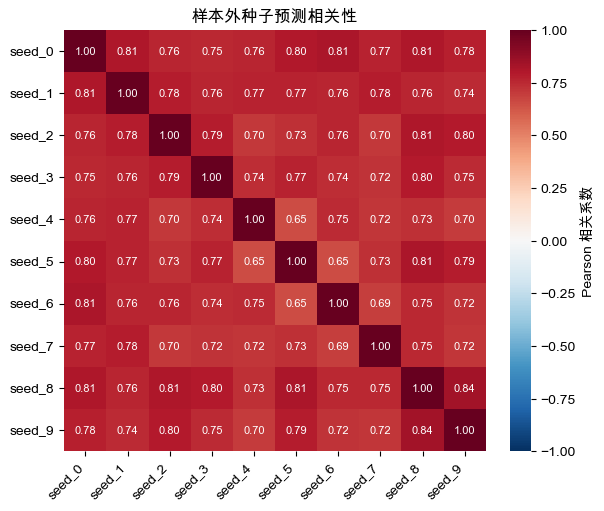

In [8]:
# 各 seed 样本外预测值的相关系数热图
plot_seed_correlation(result.predictions);

## 4. 策略样本外绩效表现

本节我们将各个 seed 产生的信号进行平均操作, 再将平均信号放到样本外回测绩效表现。 策略具体的构建方式:每天计算对未来 N 日各个指数的涨跌幅的预测值，并基于其正负号， 可以形成每日指数的多空信号:

- 若预测结果为正，则意味着模型根据当前特征 X 预测指数未来上涨可能性更高，则生成看多信号。

- 若预测结果为负，则意味着模型根据当前特征 X 预测指数未来下跌可能性更高，则生成看空信号。

我们将指数视作一个期货品种，既能做多也能做空，具体策略回测的设定如下:

- 回测区间:20200101~20251231；

- 交易价格:根据当日收盘得到的信号于次日收盘价进行买卖交易，不考虑交易费用；

- 多和空收益方式:若当日收盘信号做多则策略收益率为 T+2 收盘价除以 T+1 收盘价减 1， 若当日收盘信号做空则策略收益率为 T+1 收盘价除以 T+2 收盘价减 1;

- 调仓方式:每天观测信号是否发生切换，若发生切换则进行调仓，反之则持仓不变。

In [9]:
# 分析层：vectorbt 原生账户回测与绩效
from src.analyze import (
    backtest,            # close + signal → vectorbt Portfolio（2.5）
    backtest_frame,      # 逐日持仓、收益、净值表（2.6）
    threshold_performance
)
from src.report_reference import annual_performance

In [10]:
# 获取
score:pd.Series = result.predictions["score"].droplevel(1)

<Axes: xlabel='score', ylabel='Count'>

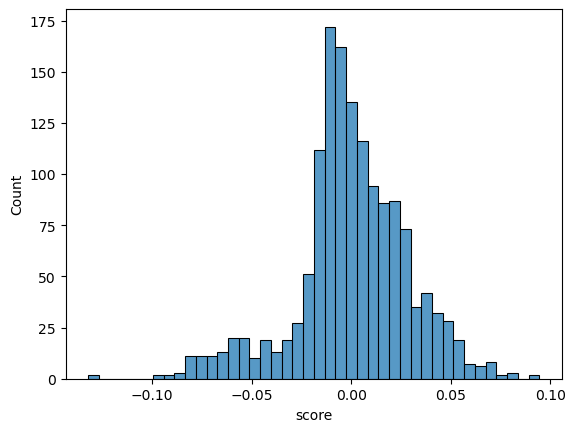

In [11]:
# 查看分布
sns.histplot(score)

### 4.1. 中证 500 指数绩效表现

由于我们在构建信号的时候, 直接使用预测值的符号函数作为最终信号, 这可能导致震荡市场环境下信号反复切换带来较高的交易成本，因此首先我们讨论了策略对阈值(k)的敏感性,即策略平均预测值大于 $\mathrm{k}$ 才进行看多,小于 $- \mathrm{k}$ 则进行看空,介于 $- \mathrm{k}$ 到 $\mathrm{k}$ 之间则维持最近一天的预判，以下是不同 $\mathrm{k}$ 取值下多空策略的绩效表现:

In [12]:
# 获取信号,1-long,-1-short
signal:pd.Series = threshold_signal(score, config.threshold)

# 收盘价
## 对齐时间
close_ser:pd.Series = index_df["close"].reindex(score.index) 

In [13]:
frames:dict = {m: backtest_frame(backtest(close_ser, signal, mode=m), signal)
          for m in ("long_short", "long_only", "short_only")}

In [14]:
threshold_format_dict:dict = {'threshold':"{:.2%}",
                              'annual_return':"{:.2%}",
                              'trade_win_rate':"{:.2%}",
                              "trades":"{:.0f}",
                              "max_drawdown":"{:.2%}"}

threshold_performance(close_ser,
                      score,
                      thresholds=(0,0.002,0.004))[list(threshold_format_dict.keys())].style.format(threshold_format_dict)

,threshold,annual_return,trade_win_rate,trades,max_drawdown
0,0.00%,29.76%,60.69%,146,-28.43%
1,0.20%,28.47%,61.74%,116,-27.50%
2,0.40%,26.85%,62.64%,92,-25.31%


本次复现中，阈值抬升的效果与研报结论并不一致：k 从 0% 提高到 0.2% 再到 0.4%，交易次数由 146 次降至 116 次、92 次，最大回撤由 −28.43% 收窄至 −27.50%、−25.31%，单笔胜率由 60.69% 升至 61.74%、62.64%，但年化收益反而由 29.76% 降至 28.47%、26.85%。也就是说，提高阈值在本次样本上买到的是更低的交易频率与回撤，而非更高的收益；且单次 run 的年化差异处在 seed 噪声量级内，上述比较不足以作为选参依据。

下面仍按默认阈值 k=0.2% 展示中证 500 指数的多空信号分布与策略绩效表现，结果如下：

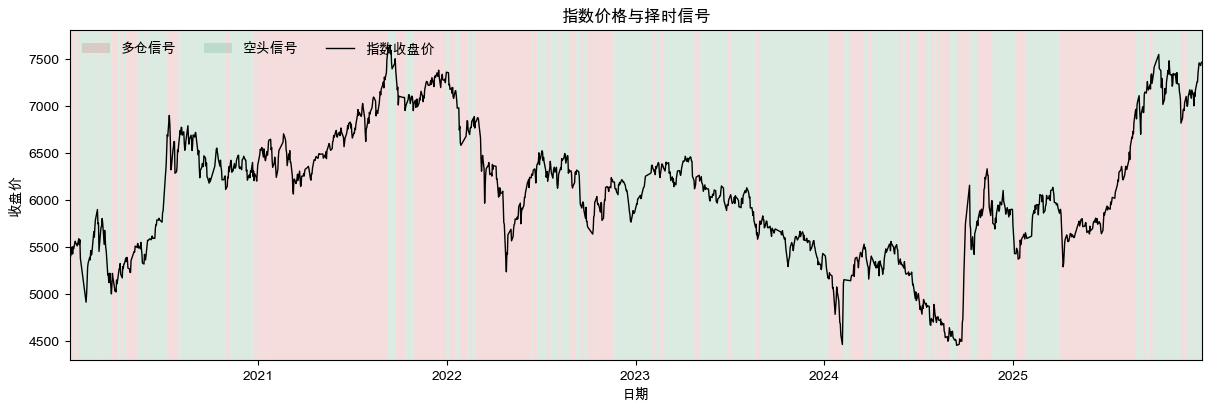

In [15]:
# 价格 + 多空背景
plot_signals(close_ser, signal);

In [16]:
format_dict:dict = {"annual_return":"{:.2%}",
                    "total_return":"{:.2%}",
                    "volatility":"{:.2%}",
                    "sharpe":"{:.2f}",
                    "max_drawdown":"{:.2%}",
                    "calmar":"{:.2f}",
                    "win_rate":"{:.2f}",
                    "drawdown_start":"{:%Y-%m-%d}",
                    "drawdown_end":"{:%Y-%m-%d}"}

annual_performance(frames['long_short'],252).style.format(format_dict,na_rep="-")

,annual_return,arithmetic_return,volatility,sharpe,max_drawdown,calmar,win_rate,trades,drawdown_start,drawdown_end
period,,,,,,,,,,
2020,-0.91%,0.022819,25.38%,-0.04,-27.50%,-0.03,0.44,27,2020-05-25,2020-08-18
2021,13.25%,0.136437,15.48%,0.86,-10.84%,1.22,0.55,7,2021-09-17,2021-10-19
2022,32.45%,0.304882,21.73%,1.49,-23.87%,1.36,0.57,24,2022-03-02,2022-04-26
2023,13.16%,0.131549,12.61%,1.04,-11.43%,1.15,0.51,10,-,2023-04-07
2024,91.71%,0.691545,28.51%,3.22,-14.62%,6.27,0.57,32,2024-01-11,2024-02-05
2025,39.58%,0.354278,20.20%,1.96,-16.06%,2.46,0.55,16,2025-01-24,2025-04-07
overall,28.47%,0.273374,21.36%,1.33,-27.50%,1.04,0.53,116,2020-05-25,2020-08-18


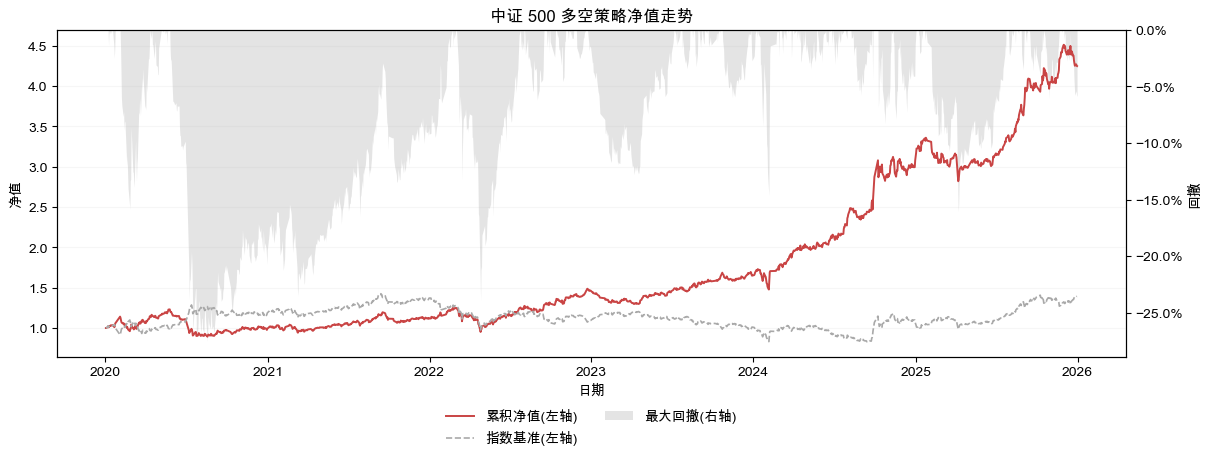

In [17]:
plot_nav_drawdown(frames['long_short'],benchmark=close_ser,title="中证 500 多空策略净值走势");

多空策略（k=0.2%，2020-01-01~2025-12-31）整体年化 28.47%、年化波动 21.36%、夏普 1.33、最大回撤 −27.50%（发生于 2020-05-25~2020-08-18）、卡玛 1.04，区间共 116 次交易。分年看差异很大：2020 年 −0.91%（夏普 −0.04）为唯一亏损年，2021、2023 年在 13% 附近，2022 年 32.45%，2024 年 91.71%（夏普 3.22）、2025 年 39.58%（夏普 1.96）。收益高度集中在 2024–2025 两年，单次 run 的年化落在 seed 噪声区间内，不宜据此外推。

中证 500 只做多绩效表现：整体年化 17.86%、夏普 1.10、最大回撤 −24.85%，58 次交易；2022、2023 年接近持平（2.85% / 2.57%），收益同样集中在 2024（43.91%）与 2025（36.89%）。

In [18]:
annual_performance(frames['long_only'],252).style.format(format_dict,na_rep="-")

,annual_return,arithmetic_return,volatility,sharpe,max_drawdown,calmar,win_rate,trades,drawdown_start,drawdown_end
period,,,,,,,,,,
2020,12.41%,0.125949,13.39%,0.93,-8.92%,1.39,0.13,14,2020-07-13,2020-07-24
2021,14.73%,0.148555,14.91%,0.99,-9.57%,1.54,0.51,3,2021-02-19,2021-03-10
2022,2.85%,0.045972,18.87%,0.15,-23.87%,0.12,0.34,12,2022-03-02,2022-04-26
2023,2.57%,0.026340,4.35%,0.59,-2.78%,0.92,0.05,5,2023-08-22,2023-08-25
2024,43.91%,0.393282,24.39%,1.80,-14.62%,3.00,0.24,16,2024-01-11,2024-02-05
2025,36.89%,0.325777,15.04%,2.45,-11.24%,3.28,0.34,8,2025-01-24,2025-04-07
overall,17.86%,0.177692,16.31%,1.10,-24.85%,0.72,0.27,58,2021-09-23,2022-04-26


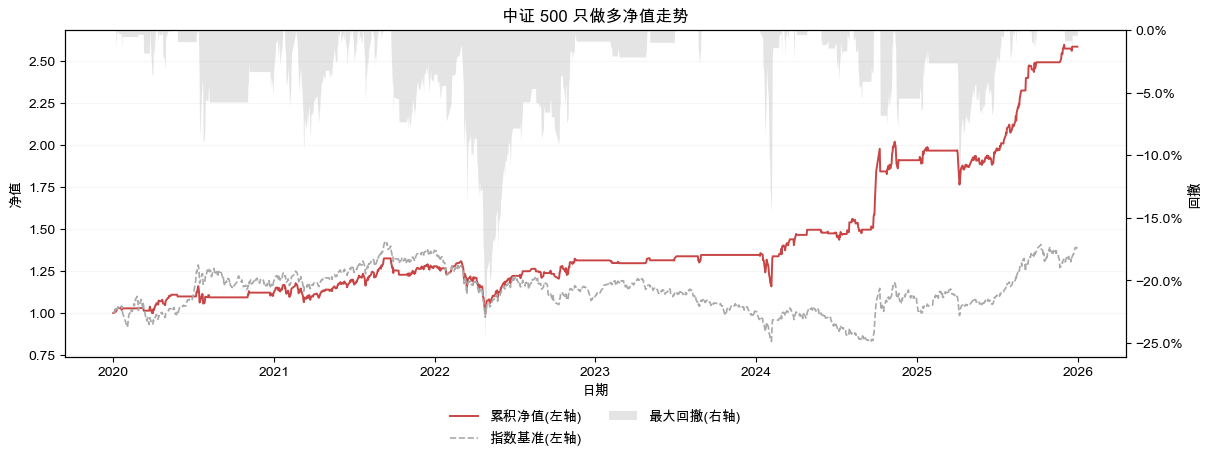

In [19]:
plot_nav_drawdown(frames['long_only'],benchmark=close_ser,title="中证 500 只做多净值走势");

中证 500 只做空绩效表现：整体年化 9.00%、夏普 0.65、最大回撤 −26.46%，58 次交易；2020、2021 年为负（−11.84% / −1.29%），2022 年 28.79%（夏普 2.66）与 2024 年 33.22% 贡献了主要收益。

In [20]:
annual_performance(frames['short_only'],252).style.format(format_dict,na_rep="-")

,annual_return,arithmetic_return,volatility,sharpe,max_drawdown,calmar,win_rate,trades,drawdown_start,drawdown_end
period,,,,,,,,,,
2020,-11.84%,-0.103130,21.54%,-0.55,-26.46%,-0.45,0.32,13,2020-02-03,2020-08-18
2021,-1.29%,-0.012118,4.12%,-0.31,-3.78%,-0.34,0.04,4,2021-09-17,2021-10-19
2022,28.79%,0.258909,10.82%,2.66,-5.36%,5.37,0.24,12,2022-08-03,2022-08-22
2023,10.32%,0.105208,11.85%,0.87,-10.29%,1.00,0.45,5,-,2023-04-07
2024,33.22%,0.298263,15.07%,2.20,-7.71%,4.31,0.33,16,2024-10-17,2024-12-12
2025,1.96%,0.028500,13.52%,0.15,-9.73%,0.20,0.21,8,2025-01-27,2025-03-18
overall,9.00%,0.095682,13.84%,0.65,-26.46%,0.34,0.27,58,2020-02-03,2020-08-18


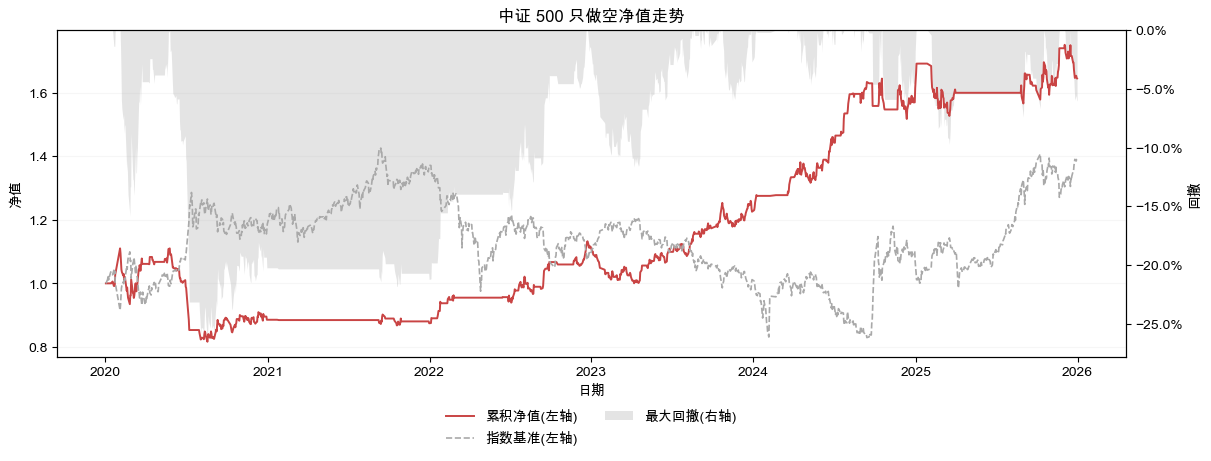

In [21]:
plot_nav_drawdown(frames['short_only'],benchmark=close_ser,title="中证 500 只做空净值走势");

## 5. 复现结论（仅中证 500）

本次复现只做了中证 500（000905.SH）一个指数，样本外区间 2020-01-01~2025-12-31，k=0.2%，10 个 seed 集成，其余参数为模块默认。以下结论的适用范围仅限该单一配置，**不能外推到其他宽基指数**（研报 §5 的「各个宽基指数上……」这类跨指数表述本次无证据支持）；中证 1000 受 TuShare 换手率起点所限训练历史过短，也不足以用来检验跨指数结论。

**训练过程（对应 3.1、3.2）**

1) 2025 训练年的四个分项损失在 100 轮内均单调趋平：稀疏惩罚前 10 轮由约 7 降到 0 附近后保持平稳，重构损失在第 15–25 轮完成主降，预测损失在第 20–60 轮稳降，10 个 seed 曲线形态一致、未见发散或持续震荡。与研报「全局下降平滑、训练稳定」的判断方向一致。

2) 10 个 seed 样本外预测两两相关系数落在 0.65–0.84，多数在 0.70 以上（研报图表 4 为 59.48%–85.30%）。形态一致，但**不能据此说「随机性影响有限」**：本项目的多 seed 稳健性实验显示，同一配置下不同单 seed 的年化样本标准差约 5–8 个百分点，单次 run 的收益差异就落在这个噪声量级内。集成取均值是为了平滑这一随机性，而不是因为随机性本身可忽略。

**样本外表现（对应第 4 节）**

3) **信号切换频率与市场环境高度相关，与研报结论一致。** 全区间共 116 个持仓段，平均 12.5 个交易日、中位仅 5 个交易日，但长尾很长：最长的单边持仓为 2021-01-22~2021-09-06 连续看多 152 个交易日，其次是 2025-03-31~2025-08-22 连续看多 100 日、2023-08-29~2024-01-05 连续看空 87 日。分年看切换次数为 2020 年 26 次、2021 年 7 次、2022 年 24 次、2023 年 10 次、2024 年 32 次、2025 年 16 次——单边年（2021、2023）切换次数只有震荡年（2020、2024）的四分之一左右。

4) **收益来源并不均衡，这一点与研报不同。** 只做多汇总年化 17.86%、只做空 9.00%，多头约为空头的 2 倍（研报为 23.30% 对 16.68%，接近均衡）。两端的年度分布还互补：只做多的收益集中在 2024（43.91%）与 2025（36.89%），只做空的收益集中在 2022（28.79%）与 2024（33.22%），而 2020、2021 年只做空为负（−11.84%、−1.29%）。因此本次复现不支持「收益不会大部分单纯来源于做多或做空」的表述。

5) **日度胜率低、赔率高的特征成立，但赔率并不高。** 多空策略日度胜率 53.13%（剔除空仓日后为 53.20%），仅比中证 500 自身的日度上涨概率 51.93% 高约 1.3 个百分点；平均盈利日 +0.99%、平均亏损日 −0.89%，赔率 1.11。即超额主要来自方向暴露的时间分配而非单日的盈亏不对称，且整体年化 28.47% 高度依赖 2024（91.71%）与 2025（39.58%）两年，2020 年为 −0.91%。

6) **阈值的作用与研报相反。** k 由 0% 抬到 0.2%、0.4%，交易次数 146→116→92、最大回撤 −28.43%→−27.50%→−25.31%、单笔胜率 60.69%→61.74%→62.64%，但年化 29.76%→28.47%→26.85% 逐档下降。本次样本上抬阈值买到的是更低的换手与回撤，而非更高的收益；并且该量级的年化差异同样落在 seed 噪声内，不足以作为选参依据。

**证伪边界**：以上只检验了单一指数（000905.SH）、单一样本外区间（2020–2025 共 6 个测试年）、固定 horizon=5、固定阈值 0.2%、单次 10-seed 集成；未测其他指数、其他 N 与阈值、其他网络宽度，也未做多次重抽以给出结论的置信区间。